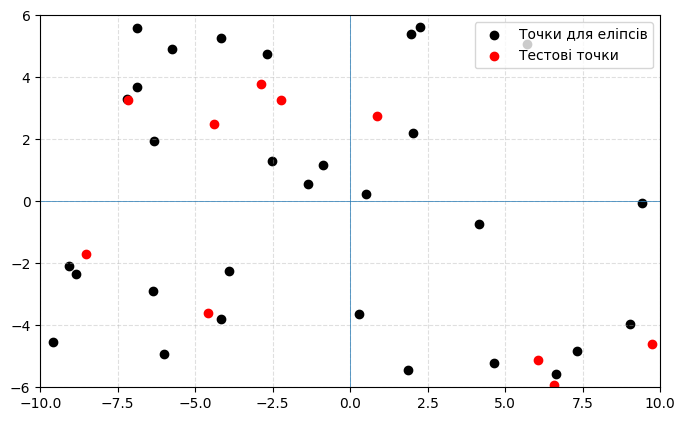

In [92]:
import numpy as np
import matplotlib.pyplot as plt

n_main = 30     
n_test = 10      
x_min, x_max = -10, 10
y_min, y_max = -6, 6
seed = 42      

np.random.seed(seed)

main_points = np.column_stack((
    np.random.uniform(x_min, x_max, n_main),
    np.random.uniform(y_min, y_max, n_main)
))

test_points = np.column_stack((
    np.random.uniform(x_min, x_max, n_test),
    np.random.uniform(y_min, y_max, n_test)
))

plt.figure(figsize=(8, 6))

plt.scatter(main_points[:, 0], main_points[:, 1],
            color='black', label='Точки для еліпсів')

plt.scatter(test_points[:, 0], test_points[:, 1],
            color='red', marker='o', label='Тестові точки')

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)

plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

plt.show()

## Дві найвіддаленіші точки 

In [93]:
def cross(o, a, b):
    """Векторний добуток (a - o) x (b - o). > 0 — лівий поворот, < 0 — правий."""
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def convex_hull(points):
    """
    Опукла оболонка за алгоритмом Грехема (Graham scan).
    """
    pts = np.asarray(points)
    n = len(pts)
    if n < 3:
        return np.arange(n)

    # нижня ліва точка - гарантовано на оболонці
    idx_ymin = np.argmin(pts[:, 1])
    y_min = pts[:, 1].min()
    cand = np.where(pts[:, 1] == y_min)[0]
    start = cand[np.argmin(pts[cand, 0])]

    # сортування за полярним кутом відносно start; при однаковому куті - далі спочатку
    angles = np.arctan2(pts[:, 1] - pts[start, 1], pts[:, 0] - pts[start, 0])
    dists = np.sum((pts - pts[start]) ** 2, axis=1)
    order = np.lexsort((-dists, angles))
    order = order[order != start]
    order = np.concatenate([[start], order])

    stack = [order[0], order[1]]
    for i in range(2, n):
        k = order[i]
        while len(stack) >= 2 and cross(pts[stack[-2]], pts[stack[-1]], pts[k]) <= 0:
            stack.pop()
        stack.append(k)

    return np.array(stack)


# оболонка для main_points
hull_vertices_idx = convex_hull(main_points)
hull_vertices = main_points[hull_vertices_idx]

# пара з максимальною відстанню
n_hull = len(hull_vertices_idx)
max_dist = 0
idx_a, idx_b = 0, 0
for i in range(n_hull):
    for j in range(i + 1, n_hull):
        d = np.linalg.norm(hull_vertices[i] - hull_vertices[j])
        if d > max_dist:
            max_dist = d
            idx_a, idx_b = i, j

i_main = hull_vertices_idx[idx_a]
j_main = hull_vertices_idx[idx_b]
far_1 = main_points[i_main]
far_2 = main_points[j_main]

print(f"Дві найвіддаленіші точки: {far_1} та {far_2}")
print(f"Відстань: {max_dist:.4f}")

Дві найвіддаленіші точки: [ 9.39819704 -0.05787708] та [-9.58831011 -4.53554118]
Відстань: 19.5074


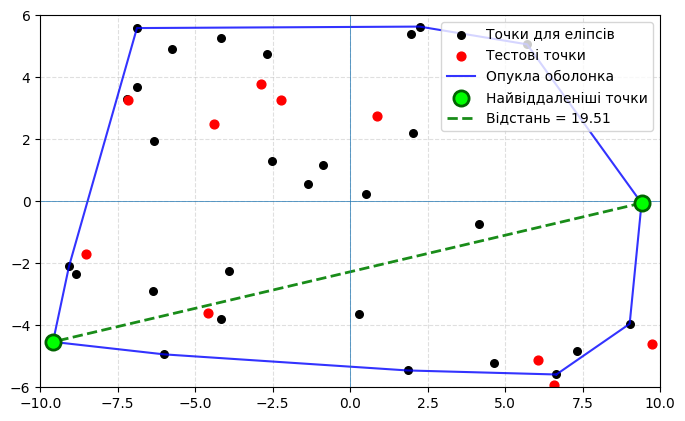

In [94]:
plt.figure(figsize=(8, 6))

plt.scatter(main_points[:, 0], main_points[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_points[:, 0], test_points[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)

# Опукла оболонка (замкнений контур)
hull_cycle = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_points[hull_cycle, 0], main_points[hull_cycle, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')

# дві найвіддаленіші точки та відрізок між ними
plt.scatter([far_1[0], far_2[0]], [far_1[1], far_2[1]], color='lime', s=120, edgecolors='darkgreen', linewidths=2, label='Найвіддаленіші точки', zorder=5)
plt.plot([far_1[0], far_2[0]], [far_1[1], far_2[1]], 'g--', linewidth=2, alpha=0.9, label=f'Відстань = {max_dist:.2f}')

plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

## Поворот системи координат

Повертаємо СК так, щоб пряма між двома найвіддаленішими точками стала горизонтальною. Напрямок цієї прямої: **d** = far_2 − far_1. Кут напрямку до осі Ox: θ = atan2(dy, dx). Матриця повороту на кут **−θ**

$$R = \begin{pmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{pmatrix}$$

Нові координати: **p'** = R **p** (для кожної точки).

In [95]:
# Напрямок прямої найвіддаленіших точок і кут з віссю Ox
d = far_2 - far_1
# Щоб поворот був мінімальним d має вказувати вправо (d[0] > 0)
if d[0] < 0:
    d = -d
theta = np.arctan2(d[1], d[0])

# Матриця повороту на −θ: після повороту вектор d співпадає з віссю Ox
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, s], [-s, c]])

# Застосовуємо поворот до всіх точок: p' = R @ p
main_points_rot = (R @ main_points.T).T
test_points_rot = (R @ test_points.T).T
far_1_rot = R @ far_1
far_2_rot = R @ far_2

print(f"Після повороту: far_1_rot = {far_1_rot}, far_2_rot = {far_2_rot}")
print(f"Різниця y (має бути ~0): {abs(far_1_rot[1] - far_2_rot[1]):.2e}")

Після повороту: far_1_rot = [ 9.13397916 -2.21356772], far_2_rot = [-10.37337662  -2.21356772]
Різниця y (має бути ~0): 4.44e-16


## Дві найвіддаленіші точки по різні боки від прямої та перпендикуляри

Знаходимо по одній точці з кожного боку горизонтальної прямої (найвіддаленіші від неї) і проводимо з них перпендикуляри до прямої. У повернутій СК пряма горизонтальна, тому відстань до неї — це |y − y_прямої|, а перпендикуляр — вертикальний відрізок.

In [96]:
# Пряма в повернутій СК горизонтальна: y = y_line
y_line = far_1_rot[1]
all_rot = np.vstack([main_points_rot, test_points_rot])

# Розділяємо точки на «вище» та «нижче» прямої
above_mask = all_rot[:, 1] > y_line
below_mask = all_rot[:, 1] < y_line

# Найвіддаленіша точка вище прямої (макс. (y - y_line))
point_above = None
if above_mask.any():
    idx_in_above = np.argmax(all_rot[above_mask, 1] - y_line)
    point_above = all_rot[above_mask][idx_in_above]

# Найвіддаленіша точка нижче прямої (макс. (y_line - y))
point_below = None
if below_mask.any():
    idx_in_below = np.argmax(y_line - all_rot[below_mask, 1])
    point_below = all_rot[below_mask][idx_in_below]

dist_above = (point_above[1] - y_line) if point_above is not None else 0
dist_below = (y_line - point_below[1]) if point_below is not None else 0
print(f"Точка вище прямої: {point_above}, відстань = {dist_above:.4f}")
print(f"Точка нижче прямої: {point_below}, відстань = {dist_below:.4f}")

Точка вище прямої: [-5.4133818   7.01752571], відстань = 9.2311
Точка нижче прямої: [ 5.03719069 -7.28445304], відстань = 5.0709


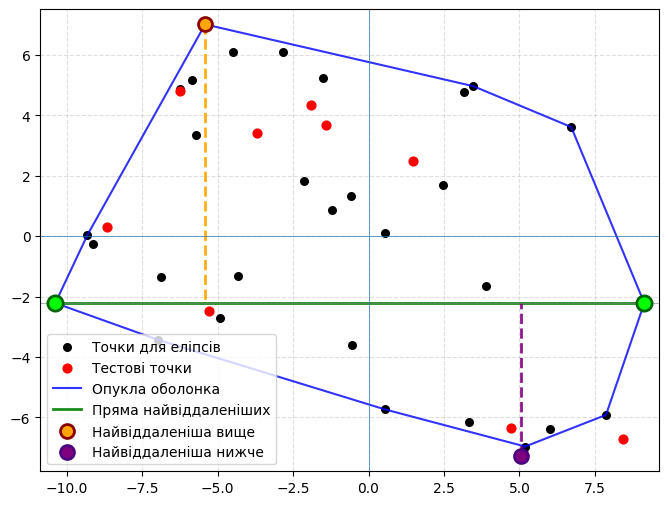

In [97]:
plt.figure(figsize=(8, 6))

plt.scatter(main_points_rot[:, 0], main_points_rot[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_points_rot[:, 0], test_points_rot[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)

hull_cycle_rot = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_points_rot[hull_cycle_rot, 0], main_points_rot[hull_cycle_rot, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')

# Горизонтальна пряма та найвіддаленіші точки на ній
plt.scatter([far_1_rot[0], far_2_rot[0]], [far_1_rot[1], far_2_rot[1]], color='lime', s=120, edgecolors='darkgreen', linewidths=2, zorder=5)
plt.plot([far_1_rot[0], far_2_rot[0]], [far_1_rot[1], far_2_rot[1]], 'g-', linewidth=2, alpha=0.9, label='Пряма найвіддаленіших')

# Дві точки по різні боки та перпендикуляри (вертикальні відрізки до прямої y = y_line)
if point_above is not None:
    plt.scatter(*point_above, color='orange', s=100, edgecolors='darkred', linewidths=2, label='Найвіддаленіша вище', zorder=5)
    plt.plot([point_above[0], point_above[0]], [point_above[1], y_line], 'orange', linestyle='--', linewidth=2, alpha=0.9)
if point_below is not None:
    plt.scatter(*point_below, color='purple', s=100, edgecolors='indigo', linewidths=2, label='Найвіддаленіша нижче', zorder=5)
    plt.plot([point_below[0], point_below[0]], [point_below[1], y_line], 'purple', linestyle='--', linewidth=2, alpha=0.9)

plt.axhline(y_line, color='gray', linewidth=0.8, alpha=0.6)
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
all_rot = np.vstack([main_points_rot, test_points_rot])
pad = 0.5
plt.xlim(all_rot[:, 0].min() - pad, all_rot[:, 0].max() + pad)
plt.ylim(all_rot[:, 1].min() - pad, all_rot[:, 1].max() + pad)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

## 4. Приведення до квадратної області

Область масштабується так, щоб **ширина = висота** і **центр зберігався**.  
Формула: **x'_i = (x_i − x_c) / k + x_c**, де **k** — коефіцієнт стискання по більшій осі (k = більша_вісь / менша_вісь). Стискаємо лише більшу вісь.

In [98]:
# Область (bounding box) у повернутій СК
all_rot = np.vstack([main_points_rot, test_points_rot])
x_min, x_max = all_rot[:, 0].min(), all_rot[:, 0].max()
y_min, y_max = all_rot[:, 1].min(), all_rot[:, 1].max()
width = x_max - x_min
height = y_max - y_min

# Центр та коефіцієнт стискання по більшій осі
x_c = (x_min + x_max) / 2
y_c = (y_min + y_max) / 2
k = max(width, height) / min(width, height)

def scale_to_square(pts, x_c, y_c, k, scale_x):
    pts = np.asarray(pts)
    if pts.ndim == 1:
        pts = pts.reshape(1, -1)
    out = pts.copy()
    if scale_x:
        out[:, 0] = (pts[:, 0] - x_c) / k + x_c
    else:
        out[:, 1] = (pts[:, 1] - y_c) / k + y_c
    return out.squeeze()

scale_x = width >= height  # стискаємо більшу вісь

# Застосовуємо масштабування до всіх точок
main_sq = scale_to_square(main_points_rot, x_c, y_c, k, scale_x)
test_sq = scale_to_square(test_points_rot, x_c, y_c, k, scale_x)
far_1_sq = scale_to_square(far_1_rot, x_c, y_c, k, scale_x)
far_2_sq = scale_to_square(far_2_rot, x_c, y_c, k, scale_x)
if point_above is not None:
    point_above_sq = scale_to_square(point_above, x_c, y_c, k, scale_x)
else:
    point_above_sq = None
if point_below is not None:
    point_below_sq = scale_to_square(point_below, x_c, y_c, k, scale_x)
else:
    point_below_sq = None

# Рівень горизонтальної прямої після масштабування
y_line_sq = (y_line - y_c) / k + y_c if not scale_x else y_line

print(f"Центр (x_c, y_c) = ({x_c:.4f}, {y_c:.4f}), k = {k:.4f}, стиск по осі: {'x' if scale_x else 'y'}")

Центр (x_c, y_c) = (-0.6197, -0.1335), k = 1.3640, стиск по осі: x


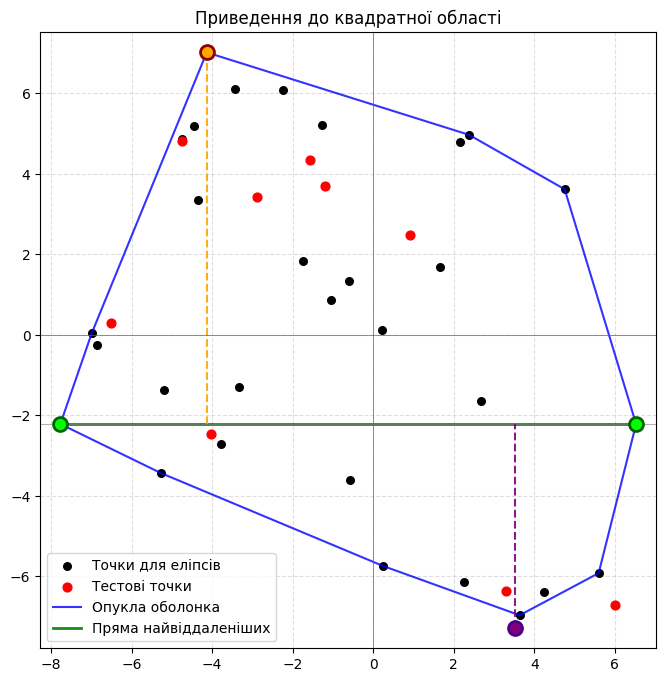

In [99]:
# Візуалізація: квадратна область
all_sq = np.vstack([main_sq, test_sq])
pad = 0.5
x_lo, x_hi = all_sq[:, 0].min() - pad, all_sq[:, 0].max() + pad
y_lo, y_hi = all_sq[:, 1].min() - pad, all_sq[:, 1].max() + pad
# Показати квадратну форму осей
r = max(x_hi - x_lo, y_hi - y_lo) / 2
mid_x = (x_lo + x_hi) / 2
mid_y = (y_lo + y_hi) / 2
plt.figure(figsize=(8, 8))
plt.scatter(main_sq[:, 0], main_sq[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=2)
plt.scatter(test_sq[:, 0], test_sq[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=2)
hull_cycle_rot = np.append(hull_vertices_idx, hull_vertices_idx[0])
plt.plot(main_sq[hull_cycle_rot, 0], main_sq[hull_cycle_rot, 1], 'b-', linewidth=1.5, alpha=0.8, label='Опукла оболонка')
plt.scatter([far_1_sq[0], far_2_sq[0]], [far_1_sq[1], far_2_sq[1]], color='lime', s=100, edgecolors='darkgreen', linewidths=2, zorder=5)
plt.plot([far_1_sq[0], far_2_sq[0]], [far_1_sq[1], far_2_sq[1]], 'g-', linewidth=2, alpha=0.9, label='Пряма найвіддаленіших')
plt.axhline(y_line_sq, color='gray', linewidth=0.8, alpha=0.6)
if point_above_sq is not None:
    plt.scatter(*point_above_sq, color='orange', s=100, edgecolors='darkred', linewidths=2, zorder=5)
    plt.plot([point_above_sq[0], point_above_sq[0]], [point_above_sq[1], y_line_sq], 'orange', linestyle='--', linewidth=1.5, alpha=0.9)
if point_below_sq is not None:
    plt.scatter(*point_below_sq, color='purple', s=100, edgecolors='indigo', linewidths=2, zorder=5)
    plt.plot([point_below_sq[0], point_below_sq[0]], [point_below_sq[1], y_line_sq], 'purple', linestyle='--', linewidth=1.5, alpha=0.9)
plt.xlim(mid_x - r, mid_x + r)
plt.ylim(mid_y - r, mid_y + r)
plt.gca().set_aspect('equal', adjustable='box')
plt.axhline(0, linewidth=0.5)
plt.axvline(0, linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title('Приведення до квадратної області')
plt.show()

## 5. Побудова вкладених кіл

У центрі квадрату будується система кіл:
- **центр** — центр квадратної області (x_c, y_c);
- **радіуси** дорівнюють відстаням від центру до кожної точки множини (main_sq).

Отримуємо впорядковані радіуси: r_1 ≤ r_2 ≤ … ≤ r_n.

In [100]:
# Центр квадратної області
center_sq = np.array([x_c, y_c])

# Відстані від центру до кожної точки множини main_sq
distances = np.linalg.norm(main_sq - center_sq, axis=1)

# Впорядковані радіуси: r_1 <= r_2 <= ... <= r_n
radii_ordered = np.sort(distances)
# Унікальні радіуси для малювання кіл (без дублікатів)
radii_unique = np.unique(radii_ordered)

print(f"Центр кіл: {center_sq}")
print(f"Кількість радіусів (точок): {len(radii_ordered)}, унікальних кіл: {len(radii_unique)}")
print(f"Радіуси (перші 5 та останні 5): {radii_ordered[:5]} ... {radii_ordered[-5:]}")

Центр кіл: [-0.61969873 -0.13346366]
Кількість радіусів (точок): 30, унікальних кіл: 29
Радіуси (перші 5 та останні 5): [0.88545171 1.07774977 1.4787804  2.26171409 2.90975077] ... [7.44738088 7.91929875 7.96797076 8.04959124 8.49460718]


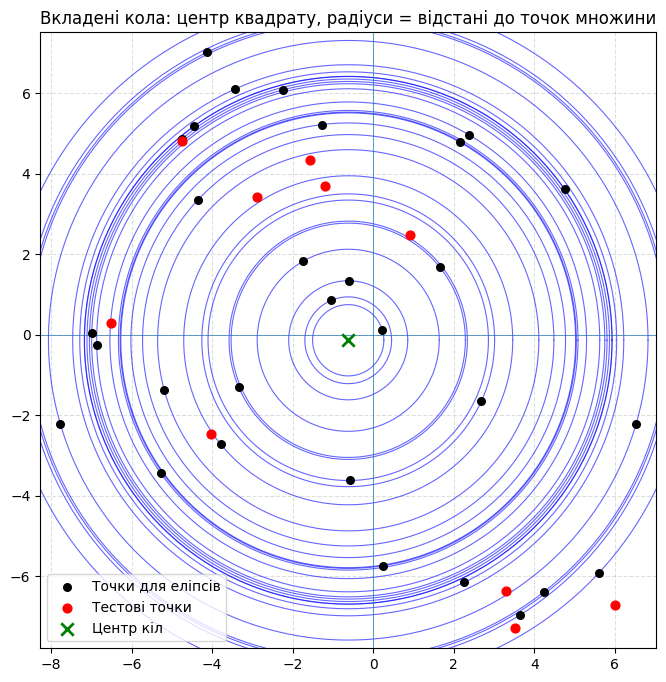

In [ ]:
# вкладені кола в центрі квадрату
fig, ax = plt.subplots(figsize=(8, 8))
theta = np.linspace(0, 2 * np.pi, 200)
for r in radii_unique:
    ax.plot(x_c + r * np.cos(theta), y_c + r * np.sin(theta), 'b-', linewidth=0.8, alpha=0.6)
ax.scatter(main_sq[:, 0], main_sq[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=3)
ax.scatter(test_sq[:, 0], test_sq[:, 1], color='red', marker='o', s=40, label='Тестові точки', zorder=3)
ax.scatter(*center_sq, color='green', s=80, marker='x', linewidths=2, label='Центр кіл', zorder=4)
all_sq = np.vstack([main_sq, test_sq])
pad = 0.5
r_plot = max(all_sq[:, 0].max() - x_c, x_c - all_sq[:, 0].min(), all_sq[:, 1].max() - y_c, y_c - all_sq[:, 1].min()) + pad
ax.set_xlim(x_c - r_plot, x_c + r_plot)
ax.set_ylim(y_c - r_plot, y_c + r_plot)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.show()

## 6. Перевірка тестових точок

Для кожної тестової точки визначаємо:
- **у скількох колах вона лежить**
- **номер максимального кола, яке її містить**

**Перевірка:** точка (x, y) лежить всередині або на колі радіуса r з центром (x_c, y_c), якщо  
(x − x_c)² + (y − y_c)² ≤ r².

In [102]:
# Відстані від центру до кожної тестової точки
dist_test = np.linalg.norm(test_sq - center_sq, axis=1)

# Для кожної тестової точки: кількість кіл, у яких вона лежить, та номер максимального кола
# Коло k (1-based) має радіус radii_ordered[k-1]. Точка всередині кола k ⟺ dist ≤ radii_ordered[k-1].
num_circles_per_point = np.sum(radii_ordered[:, np.newaxis] >= dist_test, axis=0)  # shape (n_test,)
max_circle_per_point = num_circles_per_point  # номер макс. кола = кількість кіл, що містять точку

print("Тестові точки (квадратні координати), кількість кіл")
for i in range(len(test_sq)):
    print(f"  Точка {i+1}: ({test_sq[i, 0]:.4f}, {test_sq[i, 1]:.4f}) — у {num_circles_per_point[i]} колах")

Тестові точки (квадратні координати), кількість кіл
  Точка 1: (-1.2043, 3.6908) — у 22 колах
  Точка 2: (-4.0370, -2.4692) — у 21 колах
  Точка 3: (3.5277, -7.2845) — у 1 колах
  Точка 4: (-1.5727, 4.3421) — у 21 колах
  Точка 5: (-2.8741, 3.4217) — у 21 колах
  Точка 6: (0.9064, 2.4787) — у 24 колах
  Точка 7: (-4.7422, 4.8168) — у 11 колах
  Точка 8: (3.2873, -6.3623) — у 6 колах
  Точка 9: (-6.5230, 0.3001) — у 15 колах
  Точка 10: (6.0076, -6.7217) — у 0 колах


## 7. Зворотне масштабування та ймовірність належності

Кола перетворюються назад у прямокутну область → вони стають **еліпсами**. Таким чином отримуємо систему вкладених еліпсів.

**Ймовірність належності:** якщо точка знаходиться в m-му еліпсі (з n можливих):  
**P = (m − 1) / (n + 1)**

Граничні випадки: внутрішнє коло → P ≈ 0, зовнішнє → P ≈ 1.

In [103]:
n = len(radii_ordered)  # кількість еліпсів

# Ймовірність належності для кожної тестової точки: P = (m - 1) / (n + 1)
P_test = (max_circle_per_point - 1) / (n + 1)

print("Результат: ймовірність належності тестових точок")
print("(m — номер макс. еліпса, що містить точку, n — кількість еліпсів)")
for i in range(len(test_sq)):
    m = max_circle_per_point[i]
    print(f"  Тестова точка {i+1}: m = {m}, P = (m-1)/(n+1) = {P_test[i]:.4f}")

Результат: ймовірність належності тестових точок
(m — номер макс. еліпса, що містить точку, n — кількість еліпсів)
  Тестова точка 1: m = 22, P = (m-1)/(n+1) = 0.6774
  Тестова точка 2: m = 21, P = (m-1)/(n+1) = 0.6452
  Тестова точка 3: m = 1, P = (m-1)/(n+1) = 0.0000
  Тестова точка 4: m = 21, P = (m-1)/(n+1) = 0.6452
  Тестова точка 5: m = 21, P = (m-1)/(n+1) = 0.6452
  Тестова точка 6: m = 24, P = (m-1)/(n+1) = 0.7419
  Тестова точка 7: m = 11, P = (m-1)/(n+1) = 0.3226
  Тестова точка 8: m = 6, P = (m-1)/(n+1) = 0.1613
  Тестова точка 9: m = 15, P = (m-1)/(n+1) = 0.4516
  Тестова точка 10: m = 0, P = (m-1)/(n+1) = -0.0323


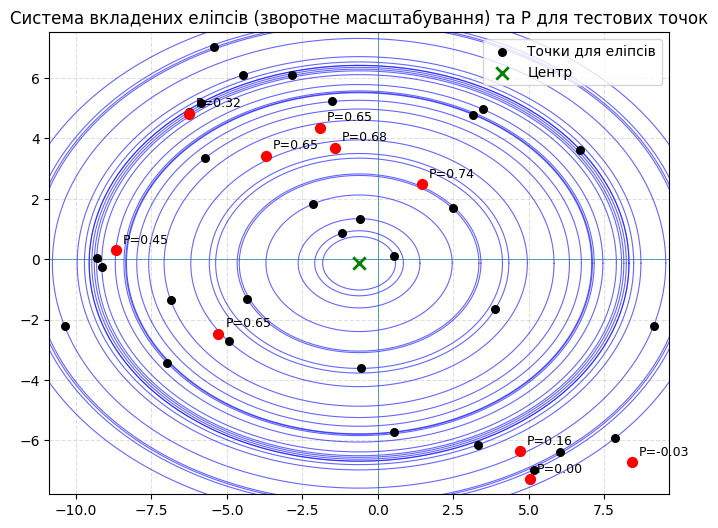

In [104]:
# Зворотне масштабування: кола в квадраті - еліпси в повернутій області
# Еліпс з кола радіуса r: півосі a, b (стискали одну вісь на k, тому обернено одна піввісь у k разів більша)
theta = np.linspace(0, 2 * np.pi, 200)
if scale_x:
    a_mult, b_mult = k, 1.0   # по x розтягуємо назад у k разів
else:
    a_mult, b_mult = 1.0, k   # по y розтягуємо назад у k разів

fig, ax = plt.subplots(figsize=(8, 6))
for r in radii_unique:
    ax.plot(x_c + a_mult * r * np.cos(theta), y_c + b_mult * r * np.sin(theta), 'b-', linewidth=0.8, alpha=0.6)
ax.scatter(main_points_rot[:, 0], main_points_rot[:, 1], color='black', s=30, label='Точки для еліпсів', zorder=3)
ax.scatter(test_points_rot[:, 0], test_points_rot[:, 1], color='red', s=50, zorder=3)
for i in range(len(test_points_rot)):
    ax.annotate(f'P={P_test[i]:.2f}', (test_points_rot[i, 0], test_points_rot[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.scatter(x_c, y_c, color='green', s=80, marker='x', linewidths=2, label='Центр', zorder=4)
all_rot = np.vstack([main_points_rot, test_points_rot])
pad = 0.5
ax.set_xlim(all_rot[:, 0].min() - pad, all_rot[:, 0].max() + pad)
ax.set_ylim(all_rot[:, 1].min() - pad, all_rot[:, 1].max() + pad)
ax.set_aspect('equal', adjustable='box')
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
ax.set_title('Система вкладених еліпсів (зворотне масштабування) та P для тестових точок')
plt.show()

TODO:

1. Збільшити кількість точок
2. Доробити площі еліпсів
3. Граничні випадки - 0 кіл
4. Площі еліпсів


